# Importing necessary Libraries 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("application_train.csv")

In [4]:
# Replacing fake values
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
# Creating meaningful features
df['AGE'] = df['DAYS_BIRTH'] / -365
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365

# Feature Engineering

In [5]:
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['INCOME_CREDIT_RATIO'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
df['EMPLOYED_AGE_RATIO'] = df['YEARS_EMPLOYED'] / df['AGE']

In [6]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [7]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [10]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

C:\Users\srina\anaconda3\envs\fraud_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic ROC-AUC: 0.6382108862378437


In [11]:
model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(X_train, y_train)

y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest ROC-AUC: 0.706208193253257


In [12]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

C:\Users\srina\anaconda3\envs\fraud_env\lib\site-packages\xgboost\training.py:200: UserWarning: [21:03:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost ROC-AUC: 0.7486502242239945


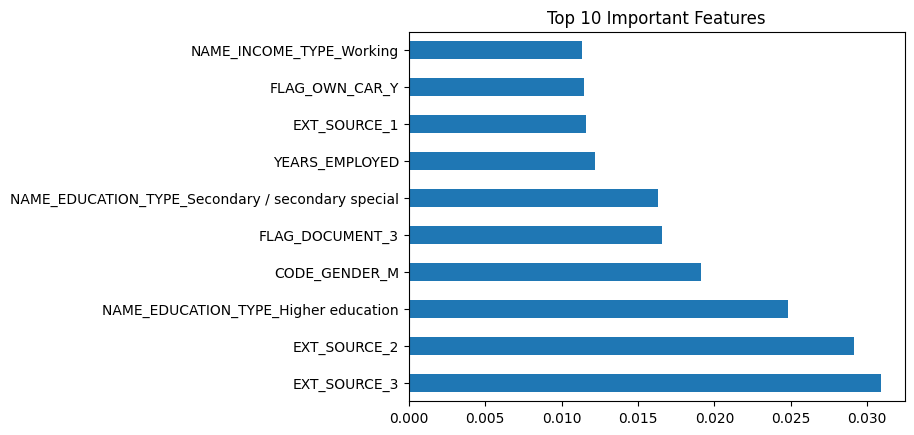

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(model_xgb.feature_importances_, index=X_train.columns)
feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

In [14]:
import joblib

joblib.dump(model_xgb, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [15]:
joblib.dump(X_train.columns, "model_columns.pkl")

['model_columns.pkl']